## EXAMEN DE RI - I BIMESTRE

#### NOMBRE: Edison Quizhpe
#### FECHA: 27/05/2026

##### 01: Cargar el corpus en la carpeta dataset.



In [2]:
import pandas as pd
import os

# Cargar los archivos CSV del corpus
corpus_path = 'dataset/'

# Cargar las películas
movies_df = pd.read_csv(os.path.join(corpus_path, 'rotten_tomatoes_movies.csv'))

# Cargar las críticas
reviews_df = pd.read_csv(os.path.join(corpus_path, 'rotten_tomatoes_critic_reviews.csv'))

print("\n=== Corpus Cargado ===")
print(f"\nMovies: {len(movies_df)} películas")
print(f"Reviews: {len(reviews_df)} críticas")


=== Corpus Cargado ===

Movies: 17712 películas
Reviews: 1130017 críticas


##### 02: Preprocesamiento 

In [3]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, wordpunct_tokenize
from nltk.stem import PorterStemmer

# Asegurar las descargas de NLTK
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)


def _tokenizar(texto):
    """Tokeniza con punkt y cae a una tokenización simple si falta punkt_tab."""
    try:
        return word_tokenize(texto)
    except LookupError:
        try:
            nltk.download('punkt_tab', quiet=True)
            return word_tokenize(texto)
        except LookupError:
            return wordpunct_tokenize(texto)

def limpiar_texto(texto):
   
    # 1. Normalización a minúsculas
    texto = str(texto).lower()
    
    # 2. Limpieza de saltos de línea y espacios dobles
    texto = re.sub(r'\s+', ' ', texto)
    
    # 3. Remover caracteres no alfabéticos (elimina puntuación)
    texto = re.sub(r'[^a-zA-Z\s]', '', texto)
    
    # 4. Tokenización
    tokens = _tokenizar(texto)
    
    # 5. Filtrado de Stopwords en inglés
    stop_words = set(stopwords.words('english'))
    tokens_filtrados = [word for word in tokens if word not in stop_words]
    
    # 6. Stemming (reducción a raíz: "pricing" -> "price", "running" -> "run")
    stemmer = PorterStemmer()
    tokens_stemmed = [stemmer.stem(word) for word in tokens_filtrados]
    
    return tokens_stemmed

muestra_reviews = reviews_df.head(10000).copy()
muestra_reviews['review_content_limpio'] = muestra_reviews['review_content'].apply(limpiar_texto)
print(f"Muestra procesada: {len(muestra_reviews)} reviews")

Muestra procesada: 10000 reviews


##### 03: Generación de Embeddings 

In [4]:
from sentence_transformers import SentenceTransformer

# Crear columna de texto limpio si no existe
if 'clean_review' not in muestra_reviews.columns:
    muestra_reviews['clean_review'] = muestra_reviews['review_content_limpio'].apply(
        lambda toks: ' '.join(toks) if isinstance(toks, list) else str(toks)
    )

# Cargar un modelo de embeddings de libre elección
model_name = 'all-MiniLM-L6-v2'  # Modelo rápido y eficiente
model = SentenceTransformer(model_name)

# Generar embeddings para los documentos del corpus (muestra)
print(f"Generando embeddings para {len(muestra_reviews)} documentos...")
corpus_embeddings = model.encode(muestra_reviews['clean_review'].tolist(), show_progress_bar=True)

# Guardar embeddings en la muestra
muestra_reviews['embedding'] = list(corpus_embeddings)
print(f"✓ Embeddings generados exitosamente")
print(f"Forma del embedding: {corpus_embeddings.shape}")

c:\Users\wwwed\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7248.67it/s]


Generando embeddings para 10000 documentos...


Batches: 100%|██████████| 313/313 [00:16<00:00, 18.45it/s]


✓ Embeddings generados exitosamente
Forma del embedding: (10000, 384)


##### 04: Procesamiento de Consultas y Recuperación

In [5]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

def retrieve_documents(query, df, corpus_embeddings, model, k=5):
 
    # Generar el embedding de la consulta
    query_embedding = model.encode([query])
    
    # Calcular la similitud coseno
    similarities = cosine_similarity(query_embedding, corpus_embeddings)[0]
    
    # Obtener los índices de los k documentos más similares
    top_k_indices = similarities.argsort()[-k:][::-1]
    
    # Construir la lista de resultados
    results = []
    for rank, idx in enumerate(top_k_indices, start=1):
        review = df.iloc[idx]
        
        # Obtener el título de la película desde movies_df
        movie_link = review.get('rotten_tomatoes_link', '')
        movie_title = 'N/A'
        if movie_link:
            movie_data = movies_df[movies_df['rotten_tomatoes_link'] == movie_link]
            if not movie_data.empty:
                movie_title = movie_data.iloc[0]['movie_title']
        
        results.append({
            'Ranking': rank,
            'ID documento': idx,
            'Título película': movie_title,
            'Fragmento de texto': review['review_content'][:150] + "...",
            'Similitud': round(similarities[idx], 4)
        })
        
    return pd.DataFrame(results)

##### 05: Benchmark de consultas

In [6]:
queries = [
    "science fiction movie with advanced technology",
    "romantic story with emotional relationships",
    "action movie with intense fight scenes",
    "horror film that creates fear and suspense",
    "visually impressive movie with weak storyline",
    "emotionally moving performance by the lead actor",
    "predictable plot but entertaining experience",
    "movie praised by critics but unpopular with audiences"
]

# Asignar df como alias para muestra_reviews (contiene los 10000 reviews procesados)
df = muestra_reviews

# Diccionario para almacenar el mejor resultado de cada consulta para la tabla resumen
top1_results = []

for i, query in enumerate(queries, start=1):
    print(f"\n--- Resultados para Q{i}: '{query}' ---")
    results_df = retrieve_documents(query, df, corpus_embeddings, model, k=5)
    
    # Mostrar la tabla con los resultados Top-k
    display(results_df)
    
    # Guardar el Top-1 para el resumen general
    top1 = results_df.iloc[0]
    top1_results.append({
        'Consulta': f"Q{i}",
        'ID documento': top1['ID documento'],
        'Título película': top1['Título película'],
        'Fragmento Top-1': top1['Fragmento de texto'],
        'Similitud': top1['Similitud']
    })


--- Resultados para Q1: 'science fiction movie with advanced technology' ---


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,7268,21,One can't help but think there was a smarter f...,0.4964
1,2,1757,The Matador,... one of the smarter films out right now....,0.4846
2,3,9443,Surrogates,While the film will make you contemplate the e...,0.4725
3,4,2317,Aliens,"An excellent science fiction, horror, action A...",0.4665
4,5,2281,Aliens,[A] modern sci-fi classic....,0.4579



--- Resultados para Q2: 'romantic story with emotional relationships' ---


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,8135,Red,A simple tale of how love and affection can so...,0.5004
1,2,5870,Married Life,"All over the place in tone, never knowing if i...",0.4674
2,3,771,The Breaking Point,"It emerges as a strong, sardonic melodrama, mo...",0.4623
3,4,9923,The Matador,A no-frills documentary for those who romantic...,0.4450
4,5,5720,The Visitor,Much more interested in its interpersonal rela...,0.4377



--- Resultados para Q3: 'action movie with intense fight scenes' ---


...

,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,5810,The Visitor,"It's a lovely, moving film, marked by memorabl...",0.5327
1,2,7760,Shutter,As pretty and bland as its lead actors....,0.4935
2,3,5631,Appaloosa,Viggo Mortensen is a trustworthy ally in the p...,0.4866
3,4,9939,The Caller,There's a vaguely appealing elegance to the wa...,0.4663
4,5,5784,The Visitor,(Richard) Jenkins doesn't waste a motion or a ...,0.4600



--- Resultados para Q7: 'predictable plot but entertaining experience' ---


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,2568,Stay Alive,"Yeah, the plot sounds like utter nonsense, but...",0.5827
1,2,8475,G-Force,The action scenes are much more impressive tha...,0.5739
2,3,9208,Julia,A nerve-wracking thriller with a twisty plot a...,0.5669
3,4,6464,The Rocker,"Predictable, but fun....",0.5102
4,5,595,The 39 Steps,A noteworthy example of Hitchcock's early thri...,0.5035



--- Resultados para Q8: 'movie praised by critics but unpopular with audiences' ---


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,8889,Public Enemies,"Public Enemies isn't a bad film, and it's most...",0.5726
1,2,4186,Deep Water,...the less said about this film the better. I...,0.5722
2,3,9500,The Promotion,"I predict that when this film is released, lot...",0.5261
3,4,9074,Public Enemies,"In a film that somewhat disapoints, casting is...",0.5255
4,5,2897,The 4th Dimension,"It is a film whose concept is too often done, ...",0.5148


##### 06: Tabla resumen general 

In [7]:
print("\n--- Tabla Resumen General (Top-1 por consulta) ---")
summary_df = pd.DataFrame(top1_results)
display(summary_df)


--- Tabla Resumen General (Top-1 por consulta) ---


,Consulta,ID documento,Título película,Fragmento Top-1,Similitud
0,Q1,7268,21,One can't help but think there was a smarter f...,0.4964
1,Q2,8135,Red,A simple tale of how love and affection can so...,0.5004
2,Q3,2317,Aliens,"An excellent science fiction, horror, action A...",0.6195
3,Q4,9246,Angel Heart,One of the few truly great modern horror films...,0.7109
4,Q5,3692,The Happening,"Horror film is long on peril, but thin on plot...",0.5901
5,Q6,5810,The Visitor,"It's a lovely, moving film, marked by memorabl...",0.5327
6,Q7,2568,Stay Alive,"Yeah, the plot sounds like utter nonsense, but...",0.5827
7,Q8,8889,Public Enemies,"Public Enemies isn't a bad film, and it's most...",0.5726


##### DESAFIOS DE EXCELENCIA

##### 07: Visualizar embeddings con PCA

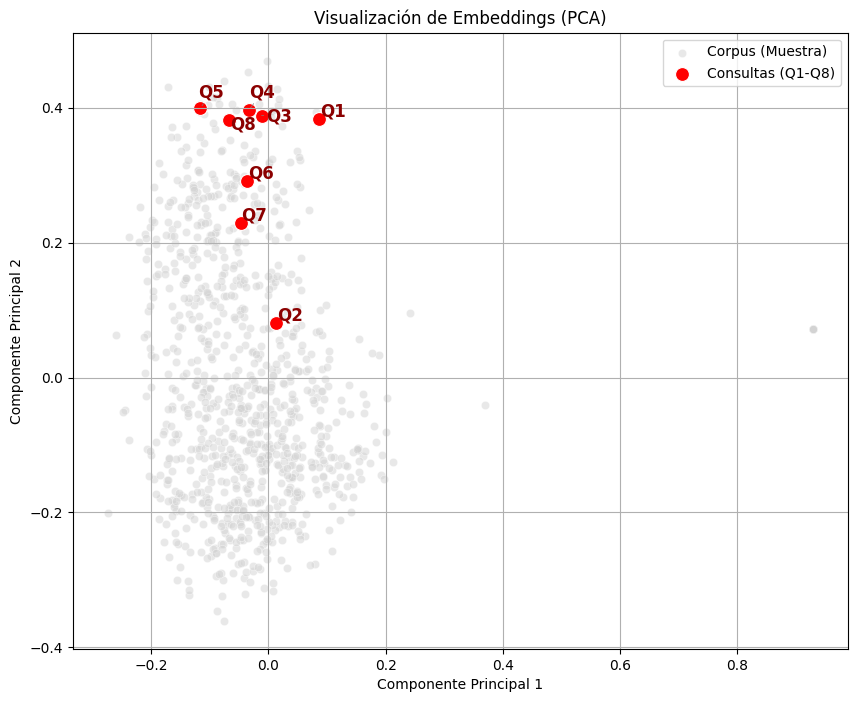

In [8]:
from adjustText import adjust_text

# Reducir la dimensionalidad de los embeddings del corpus a 2D
pca = PCA(n_components=2)
corpus_pca = pca.fit_transform(corpus_embeddings)

# Generar y reducir los embeddings de las consultas
query_embeddings = model.encode(queries)
queries_pca = pca.transform(query_embeddings)

# Graficar
plt.figure(figsize=(10, 8))

# Graficar una muestra del corpus (primeros 1000 para no saturar el gráfico)
sns.scatterplot(x=corpus_pca[:1000, 0], y=corpus_pca[:1000, 1], color='lightgray', label='Corpus (Muestra)', alpha=0.5)

# Graficar las consultas (una sola vez)
sns.scatterplot(x=queries_pca[:, 0], y=queries_pca[:, 1], color='red', s=100, label='Consultas (Q1-Q8)')

# Guardamos los objetos de texto en una lista en su posición original
textos = []
for i, (x, y) in enumerate(queries_pca):
    textos.append(plt.text(x, y, f'Q{i+1}', fontsize=12, color='darkred', weight='bold'))

# adjust_text reacomoda las etiquetas automáticamente para que no choquen
adjust_text(textos, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))

# Configuración final del gráfico (un solo título)
plt.title('Visualización de Embeddings (PCA)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.grid(True)
plt.show()

##### 08: Comparación de Modelos de Embeddings

In [9]:
import time

print("COMPARACIÓN DE DOS MODELOS DE EMBEDDINGS")

# Modelo 1: all-MiniLM-L6-v2 (ya cargado)
model1_name = 'all-MiniLM-L6-v2'
model1 = model # Reutilizar 

# Modelo 2: all-mpnet-base-v2 (mayor calidad, más lento)
model2_name = 'all-mpnet-base-v2'
print(f"\nCargando modelo 2: {model2_name}...")
model2 = SentenceTransformer(model2_name)

# Comparar con un subset pequeño (2000 documentos para no tardar mucho)
subset_size = 2000
subset_texts = muestra_reviews['clean_review'].tolist()[:subset_size]

# Modelo 1: Tiempo y dimensión
print(f"\n[Modelo 1: {model1_name}]")
start = time.time()
embeddings1 = model1.encode(subset_texts, show_progress_bar=False)
time1 = time.time() - start
print(f" Tiempo: {time1:.3f}s")
print(f" Dimensión: {embeddings1.shape}")

# Modelo 2: Tiempo y dimensión
print(f"\n[Modelo 2: {model2_name}]")
start = time.time()
embeddings2 = model2.encode(subset_texts, show_progress_bar=False)
time2 = time.time() - start
print(f" Tiempo: {time2:.3f}s")
print(f" Dimensión: {embeddings2.shape}")

# Comparar similitud en una consulta de prueba
test_query = "great movie with excellent story"
query_emb1 = model1.encode([test_query])
query_emb2 = model2.encode([test_query])

sim1 = cosine_similarity(query_emb1, embeddings1)[0]
sim2 = cosine_similarity(query_emb2, embeddings2)[0]

top_idx_m1 = sim1.argsort()[-1]
top_idx_m2 = sim2.argsort()[-1]

print(f"\n[Consulta de prueba: '{test_query}']")
print(f"Modelo 1 - Similitud máxima: {sim1[top_idx_m1]:.4f}")
print(f"Modelo 2 - Similitud máxima: {sim2[top_idx_m2]:.4f}")

print(f"\n{'='*80}")
print(f"CONCLUSIÓN:")
print(f" - Modelo 1 es {time2/time1:.1f}x más rápido")
print(f" - Modelo 2 tiene mayor capacidad expresiva (dimensión {embeddings2.shape[1]})")
print(f"{'='*80}") 

COMPARACIÓN DE DOS MODELOS DE EMBEDDINGS

Cargando modelo 2: all-mpnet-base-v2...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4891.02it/s]



[Modelo 1: all-MiniLM-L6-v2]
 Tiempo: 3.462s
 Dimensión: (2000, 384)

[Modelo 2: all-mpnet-base-v2]
 Tiempo: 22.833s
 Dimensión: (2000, 768)

[Consulta de prueba: 'great movie with excellent story']
Modelo 1 - Similitud máxima: 0.4671
Modelo 2 - Similitud máxima: 0.6245

CONCLUSIÓN:
 - Modelo 1 es 6.6x más rápido
 - Modelo 2 tiene mayor capacidad expresiva (dimensión 768)


In [10]:
from dotenv import load_dotenv
import os

load_dotenv()
api_key = os.getenv("api_key")

In [11]:
prompt = "Eres un chatbot conversacional. Mi usuario quiere saber acerca de {Query}. Mi sistema de recuperacion de informacion encontro: {Resultados}. Dame la respuesta en base al contexto dado por el sistema de recuperacion de informacion."

In [12]:
#from collection import dequeue

#contexto = dequeue()
#contexto.append(prompt)
#contexto.append(response.text)
#contexto.append("Ya pero cual es mas antigua?")

In [13]:
#print(str(contexto))

In [14]:

from google import genai

client = genai.Client(api_key=api_key)

mensaje = prompt.format(
    Query=query,            
    Resultados=results_df.to_string() 
)
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=mensaje,
)

print(response.text)

Basándome en la información proporcionada por el sistema de recuperación, la película que se acerca más a la descripción de ser "elogiada por la crítica pero impopular con las audiencias" es **The Promotion**.

El fragmento sobre **The Promotion** (ID 9500) indica: "I predict that when this film is released, lots of critics who miss the point will complain about its muted tone. Scott and Reilly actually underplay...". Esto sugiere que la película tiene una intención artística ("underplay") que podría no ser comprendida o apreciada por todos los críticos, y por extensión, podría ser malinterpretada o no popular entre el público general, a pesar de tener un valor intrínseco.

Para las otras películas:
*   **Public Enemies** (ID 8889 y 9074) se describe como "no es una mala película" o "una película que decepciona un poco", lo que no se alinea con ser "elogiada por la crítica".
*   **Deep Water** (ID 4186) tiene un fragmento muy ambiguo ("...the less said about this film the better. It's 